# 01 — Corpus overview and sanity checks

Objective: verify the corpus is what `data_README.md` and `build_corpus.py` claim
before trusting any downstream analysis on it. This notebook doesn't compute
anything new — it re-derives the same sanity checks `build_corpus.py` already
performs (deduplication, PMQs tagging) and visualizes the volume/coverage of
each PM's tenure, using the already-cleaned corpus in `data/processed/`.

See `CLAUDE.md` §6: reusable logic lives in `src/hansard_pm_nlp/`, this
notebook only imports it.


In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))

sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 120)

df = pd.read_parquet(str(PROJECT_ROOT / "data" / "processed" / "pm_contributions_clean.parquet"))
df["sitting_date"] = pd.to_datetime(df["sitting_date"])
df.shape


(10673, 18)

## 1. Shape, dtypes, date range

In [2]:
print(f"{len(df):,} contributions, {df['sitting_date'].nunique()} distinct sitting dates")
print(f"Date range: {df['sitting_date'].min().date()} -> {df['sitting_date'].max().date()}")
df.dtypes


10,673 contributions, 298 distinct sitting dates
Date range: 2019-07-25 -> 2026-07-15


pm_name                                    str
pm_party                                   str
member_id                                int64
item_id                                  int64
contribution_ext_id                        str
contribution_text                          str
hansard_section                            str
debate_section                             str
debate_section_id                        int64
debate_section_ext_id                      str
sitting_date                    datetime64[us]
section                                    str
house                                      str
order_in_debate_section                  int64
debate_section_order                     int64
ingested_at                datetime64[us, UTC]
contribution_text_raw                      str
is_pmqs                                   bool
dtype: object

## 2. Duplicate check

`build_corpus.py`'s `data_README.md` claims 5 exact-duplicate-text rows
(same PM/date/text) were found and kept deliberately — distinct short
interjections ("Sit down.", "No.") with distinct `contribution_ext_id`, not
ingestion artifacts. Re-deriving that here rather than trusting the claim.


In [3]:
dupe_mask = df.duplicated(subset=["pm_name", "sitting_date", "contribution_text"], keep=False)
dupes = df.loc[dupe_mask, ["pm_name", "sitting_date", "contribution_text", "contribution_ext_id"]]
print(f"{len(dupes)} rows involved in exact-duplicate (pm, date, text) groups")
dupes.sort_values(["pm_name", "sitting_date"])


7 rows involved in exact-duplicate (pm, date, text) groups


,pm_name,sitting_date,contribution_text,contribution_ext_id
226,Boris Johnson,2019-09-04,rose—[Interruption.],113E5CA9-FBD2-4445-B957-A18CD18BEB26
233,Boris Johnson,2019-09-04,rose—[Interruption.],2E249DCF-F155-45F3-AE24-FB3248FF2B89
600,Boris Johnson,2019-10-22,Sit down.,3D889520-F1FC-4867-812B-519032A14D46
601,Boris Johnson,2019-10-22,Sit down.,AF112615-801A-497F-A9EF-FD2CF50505FD
4517,Boris Johnson,2022-01-31,No.,5752782A-5842-4F6B-AEDA-744882A0DD53
4518,Boris Johnson,2022-01-31,No.,EABE91C8-3DC1-49D0-AEDF-2156BE33402E
4532,Boris Johnson,2022-01-31,No.,FC2CA3B1-7157-468C-95F8-FDBFCD3307E4


These are short, generic interjections that legitimately recur (a PM saying
"No." twice in one sitting isn't a duplicate ingestion, it is two separate
answers) — each has a distinct `contribution_ext_id`, so no rows should be
dropped. The rationale in `data_README.md` holds, but its **count is
stale**: it says 5 rows, this run finds 7 (3 in the 2022-01-31 "No." group,
not 2) — the corpus was evidently re-extracted with a later cutoff since
that file was last generated, adding one more legitimate "No." to that
sitting. Worth a deliberate re-run of `build_corpus.py` to refresh
`data_README.md`'s numbers (per `CLAUDE.md` §9, that refresh is a
deliberate action, not something to do silently as a side effect of this
notebook).


## 3. Volume per PM: contributions and word count

In [4]:
df["word_count"] = df["contribution_text"].str.split().str.len()

volume = df.groupby("pm_name").agg(
    n_contributions=("contribution_text", "size"),
    total_words=("word_count", "sum"),
    n_sittings=("sitting_date", "nunique"),
).sort_values("n_contributions", ascending=False)
volume


,n_contributions,total_words,n_sittings
pm_name,,,
Boris Johnson,5459,517607,145
Keir Starmer,2896,283417,85
Rishi Sunak,2195,220819,63
Liz Truss,123,8780,5


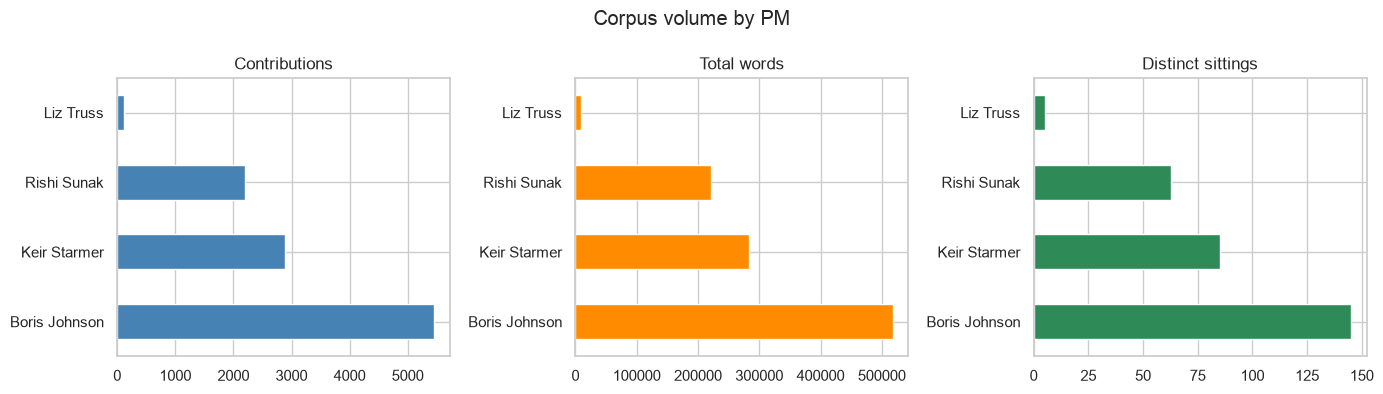

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
volume["n_contributions"].plot.barh(ax=axes[0], color="steelblue")
axes[0].set_title("Contributions")
volume["total_words"].plot.barh(ax=axes[1], color="darkorange")
axes[1].set_title("Total words")
volume["n_sittings"].plot.barh(ax=axes[2], color="seagreen")
axes[2].set_title("Distinct sittings")
for ax in axes:
    ax.set_ylabel("")
fig.suptitle("Corpus volume by PM")
fig.tight_layout()


Liz Truss sits at roughly 2% of Boris Johnson's word count — a scale gap that
matters for every later notebook and for the dashboard's decision to exclude
her from the classifier (Phase 6) while keeping her in the event study (she's
the only PM covering the mini-budget window).


## 4. PMQs vs. other debates

In [6]:
pmqs_split = df.groupby("pm_name")["is_pmqs"].agg(["mean", "sum", "size"])
pmqs_split.columns = ["pmqs_share", "n_pmqs", "n_total"]
pmqs_split


,pmqs_share,n_pmqs,n_total
pm_name,,,
Boris Johnson,0.493314,2693,5459
Keir Starmer,0.630180,1825,2896
Liz Truss,0.788618,97,123
Rishi Sunak,0.665604,1461,2195


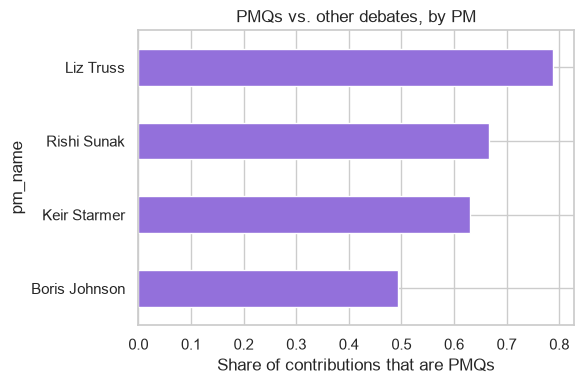

In [7]:
fig, ax = plt.subplots(figsize=(6, 4))
pmqs_split["pmqs_share"].sort_values().plot.barh(ax=ax, color="mediumpurple")
ax.set_xlabel("Share of contributions that are PMQs")
ax.set_title("PMQs vs. other debates, by PM")
fig.tight_layout()


Every PM sits between 49% and 79% PMQs. Truss's 79% is partly a tenure-length
artifact — 49 days barely covers any non-PMQs set-piece debates — worth
remembering whenever a PM comparison doesn't control for debate type.


## 5. Contribution length distribution

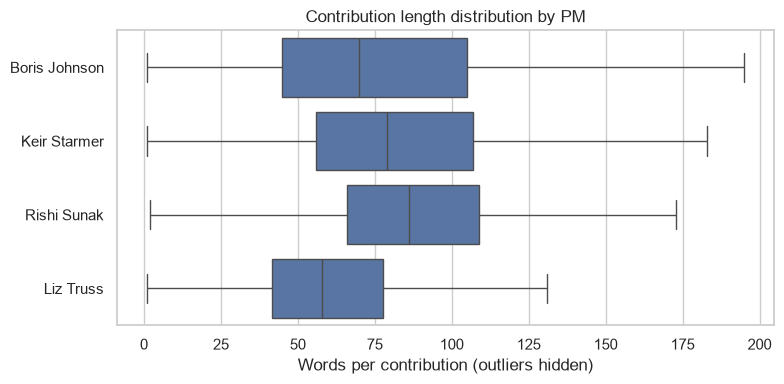

In [8]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.boxplot(data=df, x="word_count", y="pm_name", ax=ax, showfliers=False, order=volume.index)
ax.set_xlabel("Words per contribution (outliers hidden)")
ax.set_ylabel("")
ax.set_title("Contribution length distribution by PM")
fig.tight_layout()


In [9]:
short = df[df["word_count"] < 50]
print(f"{len(short)} / {len(df)} contributions are under 50 words "
      f"({len(short) / len(df):.1%})")
short["word_count"].describe()


2465 / 10673 contributions are under 50 words (23.1%)


count    2465.000000
mean       31.982150
std        12.735751
min         1.000000
25%        24.000000
50%        35.000000
75%        42.000000
max        49.000000
Name: word_count, dtype: float64

Most contributions are short — PMQs is rapid-fire back-and-forth, not
monologues. This is exactly why Phase 5's LDA model aggregates to one
document per (PM, sitting date) rather than per contribution: 2 of those
296 aggregated documents still fell under the 50-word floor and were
dropped (`phase5_lda_report.md`). At the raw contribution level the
short-document problem is much bigger, which is the point.


## 6. Sitting calendar: when did each PM actually speak

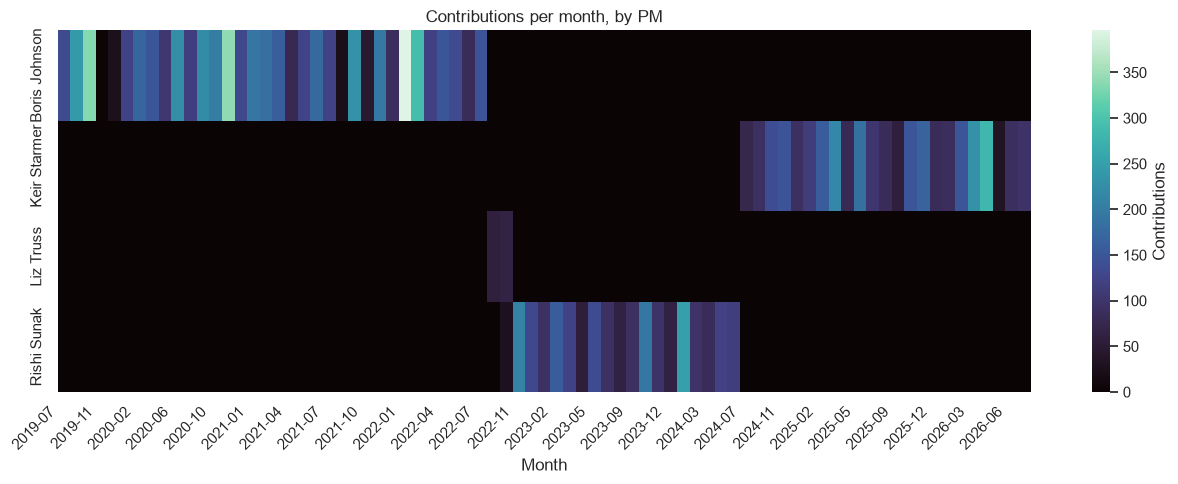

In [10]:
calendar = (
    df.groupby([pd.Grouper(key="sitting_date", freq="MS"), "pm_name"])
    .size()
    .unstack("pm_name")
    .fillna(0)
)
fig, ax = plt.subplots(figsize=(13, 5))
sns.heatmap(calendar.T, cmap="mako", cbar_kws={"label": "Contributions"}, ax=ax)
ax.set_xlabel("Month")
ax.set_ylabel("")
ax.set_title("Contributions per month, by PM")
n = len(calendar)
step = max(n // 20, 1)
ax.set_xticks(range(0, n, step))
ax.set_xticklabels([d.strftime("%Y-%m") for d in calendar.index[::step]], rotation=45, ha="right")
fig.tight_layout()


**Takeaways**

- Tenure boundaries are visually sharp — no PM's activity bleeds into
  another's window, consistent with the temporal-join tenure resolution in
  `hansard-pm-extraction`.
- Vertical gaps (near-zero months) line up with parliamentary recess
  (summer, Christmas, Easter) rather than missing data — worth knowing
  before treating a quiet month in the affect/topics dashboards as a
  rhetorical signal instead of "Parliament wasn't sitting."
- Truss's entire tenure is one thin band — any statistic computed on her
  alone (including her row in the stylometric radar) rests on 49 days of
  data, a point the dashboard's caption already flags but is easy to
  under-weight without seeing it against the other three PMs' bands.
